<a href="https://colab.research.google.com/github/Leslyndizeye/Ubuzima_Connect/blob/main/notebooks/Ubuzima_Connect_building_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
!pip install kagglehub --quiet
!pip install tensorflow opencv-python matplotlib pandas --quiet

import os
import shutil
import random
import cv2
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 845.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 20.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


#Preparing folders

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/ubuzima_data'

CLASSES = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']

# Creating/Clearing folders
for folder in CLASSES:
    path = os.path.join(drive_path, folder)
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

print(" Folders are ready at:", drive_path)

Mounted at /content/drive
 Folders are ready at: /content/drive/MyDrive/ubuzima_data


# Downloading datasets

In [ ]:
# downloading datasets
print("Downloading NIH ChestX-ray14 dataset")
nih_path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Downloading TB dataset")
tb_path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")

print(" NIH path:", nih_path)
print(" TB path:", tb_path)

100%|██████████| 42.0G/42.0G [11:12<00:00, 67.1MB/s]

Extracting files...


Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.
 NIH path: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3
 TB path: /kaggle/input/tuberculosis-tb-chest-xray-dataset


# Mapping NIH image locations

In [ ]:
print("Mapping NIH image locations (this may take a minute)...")

nih_img_map = {}
for root, dirs, files in os.walk(nih_path):
    for file in files:
        if file.lower().endswith('.png'):
            nih_img_map[file] = os.path.join(root, file)

print(f" Found {len(nih_img_map)} NIH images.")

Mapping NIH image locations (this may take a minute)...
 Found 112120 NIH images.


# Preprocessing

In [ ]:
def preprocess_and_save(src_path, dst_path):
    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False

    img = cv2.resize(img, (512, 512))

    # CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Save as PNG
    cv2.imwrite(dst_path, img)
    return True

# Loading NIH CSV

In [ ]:
csv_path = os.path.join(nih_path, "Data_Entry_2017.csv")
df = pd.read_csv(csv_path)

print("NIH CSV loaded:", csv_path)
print("Rows:", len(df))
print(df.head(3))

NIH CSV loaded: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/Data_Entry_2017.csv
Rows: 112120
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN  
1                        0.143  0.143          NaN  
2                        0.168  0.168          NaN  


# Build lists (Normal / Pneumonia / Unknown)

In [ ]:
# Normal = exact "No Finding"
normal_list = df[df['Finding Labels'] == 'No Finding']['Image Index'].tolist()

# Pneumonia = contains Pneumonia (may be multi-label that's ok)
pneu_list = df[df['Finding Labels'].str.contains('Pneumonia', na=False)]['Image Index'].tolist()

# Unknown = "Other Findings": NOT No Finding and NOT Pneumonia
unknown_list = df[
    (df['Finding Labels'] != 'No Finding') &
    (~df['Finding Labels'].str.contains('Pneumonia', na=False))
]['Image Index'].tolist()

random.shuffle(normal_list)
random.shuffle(pneu_list)
random.shuffle(unknown_list)

print(" List sizes (raw):")
print("Normal:", len(normal_list))
print("Pneumonia:", len(pneu_list))
print("Unknown (other findings):", len(unknown_list))

 List sizes (raw):
Normal: 60361
Pneumonia: 1431
Unknown (other findings): 50328


# Processing Normal (3000 images)

In [ ]:
print("Processing Normal images...")

n_count = 0
for name in normal_list[:3000]:
    if name in nih_img_map:
        dst = os.path.join(drive_path, 'Normal', name)
        if preprocess_and_save(nih_img_map[name], dst):
            n_count += 1

print(f" Normal images saved: {n_count}")

Processing Normal images...
 Normal images saved: 3000


# Process Pneumonia (1500 then augment)

In [ ]:
print("Processing Pneumonia images...")

p_count = 0
for name in pneu_list[:1500]:  # base then augment
    if name in nih_img_map:
        dst = os.path.join(drive_path, 'Pneumonia', name)
        if preprocess_and_save(nih_img_map[name], dst):
            p_count += 1

print(f" Pneumonia base images saved: {p_count}")

Processing Pneumonia images...
 Pneumonia base images saved: 1431


# Process Unknown (1500 then augment)

In [ ]:
print("Processing Unknown (Other Findings) images...")

u_count = 0
for name in unknown_list[:1500]:  # base then augment
    if name in nih_img_map:
        dst = os.path.join(drive_path, 'Unknown', name)
        if preprocess_and_save(nih_img_map[name], dst):
            u_count += 1

print(f" Unknown base images saved: {u_count}")

Processing Unknown (Other Findings) images...
 Unknown base images saved: 1500


In [ ]:
print("Downloading Random Image Sample dataset...")
rand_path = kagglehub.dataset_download("pankajkumar2002/random-image-sample-dataset")
print(" Random dataset path:", rand_path)

# Collecting image paths from it
rand_imgs = []
for root, dirs, files in os.walk(rand_path):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
            rand_imgs.append(os.path.join(root, f))

random.shuffle(rand_imgs)

UNKNOWN_RANDOM_COUNT = 300
unknown_folder = os.path.join(drive_path, 'Unknown')

print(f"Adding {UNKNOWN_RANDOM_COUNT} random non-CXR images into Unknown...")
added = 0
for i, src in enumerate(rand_imgs[:UNKNOWN_RANDOM_COUNT]):
    dst = os.path.join(unknown_folder, f"rand_{i}.png")
    if preprocess_and_save(src, dst):   # reuse your preprocessing and saving
        added += 1

print(f" added random images: {added}")

100%|██████████| 42.5M/42.5M [00:00<00:00, 154MB/s]

Extracting files...


 Random dataset path: /root/.cache/kagglehub/datasets/pankajkumar2002/random-image-sample-dataset/versions/1
Adding 300 random non-CXR images into Unknown...
 added random images: 300


# Finding TB folder robustly

In [ ]:
tb_src = None
for root, dirs, files in os.walk(tb_path):
    # common naming patterns
    if 'Tuberculosis' in dirs:
        tb_src = os.path.join(root, 'Tuberculosis')
        break
    if 'TB' in dirs:
        tb_src = os.path.join(root, 'TB')
        break

if tb_src is None:
    raise FileNotFoundError(" Could not find TB folder inside the Kaggle TB dataset download.")

print(" TB folder found:", tb_src)

 TB folder found: /kaggle/input/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database/Tuberculosis


# Processing TB

In [ ]:
print("Processing TB images...")

tb_files = [f for f in os.listdir(tb_src) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(tb_files)

t_count = 0
for name in tb_files[:700]:
    src = os.path.join(tb_src, name)
    dst = os.path.join(drive_path, 'Tuberculosis', name if name.lower().endswith('.png') else name + ".png")
    if preprocess_and_save(src, dst):
        t_count += 1

print(f" TB base images saved: {t_count}")

Processing TB images...
 TB base images saved: 700


# Data augmentation setup

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

def augment_folder(folder_name, target=3000):
    folder_path = os.path.join(drive_path, folder_name)
    current_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.png')]
    count = len(current_files)

    if count == 0:
        raise ValueError(f"Folder {folder_name} is empty. Cannot augment.")

    print(f"Augmenting {folder_name} from {count} to {target}...")

    i = 0
    while count < target:
        img_name = current_files[i % len(current_files)]
        img = cv2.imread(os.path.join(folder_path, img_name), cv2.IMREAD_GRAYSCALE)

        if img is None:
            i += 1
            continue

        x = img.reshape((1, 512, 512, 1))

        for _ in datagen.flow(
            x,
            batch_size=1,
            save_to_dir=folder_path,
            save_prefix='aug',
            save_format='png'
        ):
            count += 1
            break

        i += 1

    print(f"{folder_name} total after augmentation: {count}")

# Augment to 3000 per class

In [ ]:
augment_folder('Pneumonia', 3000)
augment_folder('Tuberculosis', 3000)
augment_folder('Unknown', 3000)

Augmenting Pneumonia from 1431 to 3000...
Pneumonia total after augmentation: 3000
Augmenting Tuberculosis from 700 to 3000...
Tuberculosis total after augmentation: 3000
Augmenting Unknown from 300 to 3000...
Unknown total after augmentation: 3000


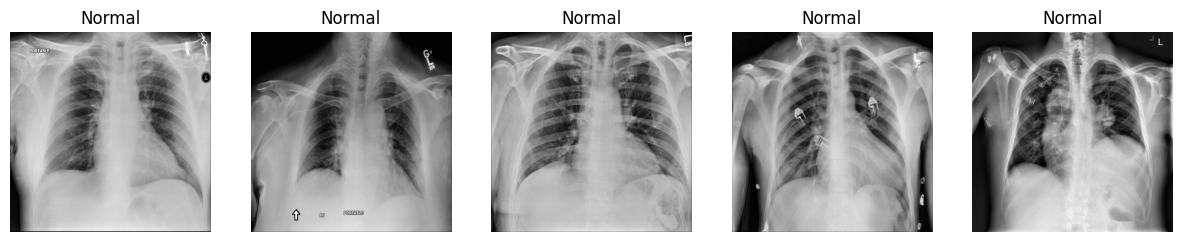

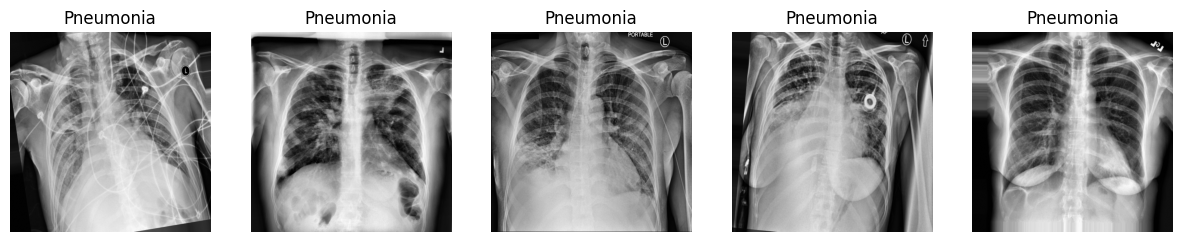

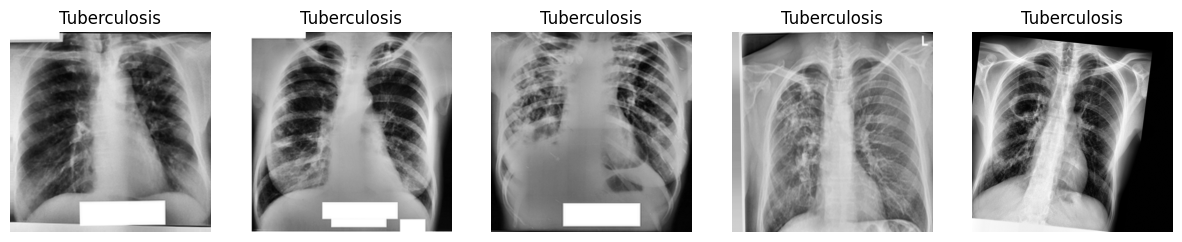

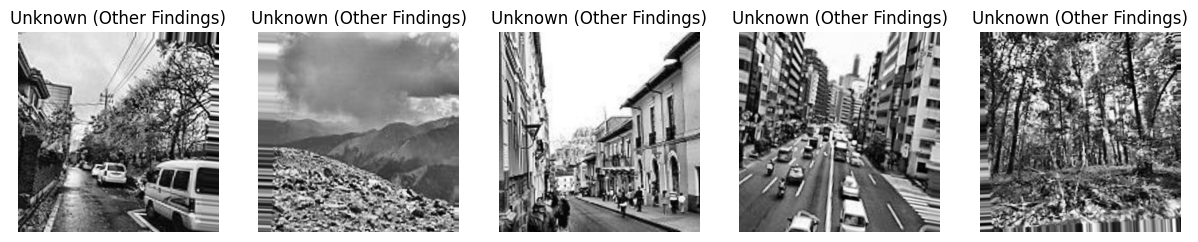

In [ ]:
def show_samples(folder_path, class_name, n=5):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith('.png')]
    sample_files = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(15, 3))
    for i, fname in enumerate(sample_files):
        img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(class_name)
    plt.show()

show_samples(os.path.join(drive_path, 'Normal'), 'Normal')
show_samples(os.path.join(drive_path, 'Pneumonia'), 'Pneumonia')
show_samples(os.path.join(drive_path, 'Tuberculosis'), 'Tuberculosis')
show_samples(os.path.join(drive_path, 'Unknown'), 'Unknown (Other Findings)')

In [ ]:
print("\nFinal dataset summary:")
for folder in CLASSES:
    cnt = len([f for f in os.listdir(os.path.join(drive_path, folder)) if f.lower().endswith('.png')])
    print(f"- {folder}: {cnt} images")

print("\n Dataset ready! All images are preprocessed, augmented, and verified.")
print("Saved at:", drive_path)


Final dataset summary:
- Normal: 3000 images
- Pneumonia: 2879 images
- Tuberculosis: 2757 images
- Unknown: 2681 images

 Dataset ready! All images are preprocessed, augmented, and verified.
Saved at: /content/drive/MyDrive/ubuzima_data
